<a href="https://colab.research.google.com/github/hieuvous/Secure-Virtual-Assistant-with-Speaker-Recognition/blob/feature%2Ffinetune-colab/notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA — Vietnam-Celeb-T for ECAPA fine-tuning
This notebook downloads the official Vietnam-Celeb release and analyses the exact `train.csv`, `val.csv`, and speaker-disjoint `dev.csv` generated by this project's subset-preparation script. It deliberately does **not** use Vietnam-Celeb-E/H test trials.

> **FINAL CONFIG NOTE:** This copy is aligned with the released Epoch-10 model: `TRAIN_SPEAKERS=600`, `DEV_SPEAKERS=50`, `MAX_UTTS=20`, `SEED=42`. The earlier 300-speaker EDA was exploratory and should not be used for final report counts.


In [2]:
# Run in Google Colab. Clone the same project code used for fine-tuning.
!git clone -b feature/finetune-colab https://github.com/hieuvous/Secure-Virtual-Assistant-with-Speaker-Recognition.git
%cd /content/Secure-Virtual-Assistant-with-Speaker-Recognition
!pip install -q gdown pandas matplotlib seaborn soundfile

Cloning into 'Secure-Virtual-Assistant-with-Speaker-Recognition'...
remote: Enumerating objects: 93, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 93 (delta 33), reused 81 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (93/93), 38.94 KiB | 1.08 MiB/s, done.
Resolving deltas: 100% (33/33), done.
/content/Secure-Virtual-Assistant-with-Speaker-Recognition


## Download the official release
The official release is split into four zip parts. This may require substantial temporary Colab disk space; download only when the runtime has enough free space.

In [3]:
# Official Vietnam-Celeb Interspeech release links. Files stay in /content, not Google Drive.
!gdown --fuzzy 'https://drive.google.com/file/d/1pMuT3DFzSwib7SVcRS8VkDwPuLTsemSG/view?usp=share_link'
!gdown --fuzzy 'https://drive.google.com/file/d/1xayHt2HRqE1aJ4HvtUT40_9XlgvfDfRY/view?usp=share_link'
!gdown --fuzzy 'https://drive.google.com/file/d/1MIlM78EbN_J9cApkNes_2_BrFrf8XwMc/view?usp=share_link'
!gdown --fuzzy 'https://drive.google.com/file/d/1h6Na58DC03p-502B9QpC5Z_FadUwAdNA/view?usp=share_link'
!ls -lh

Downloading...
From (original): https://drive.google.com/uc?id=1pMuT3DFzSwib7SVcRS8VkDwPuLTsemSG
From (redirected): https://drive.google.com/uc?id=1pMuT3DFzSwib7SVcRS8VkDwPuLTsemSG&confirm=t&uuid=45afe887-4d48-447d-83a6-87e10a408108
To: /content/Secure-Virtual-Assistant-with-Speaker-Recognition/vietnam-celeb-part.zip
100% 3.57G/3.57G [00:42<00:00, 84.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1xayHt2HRqE1aJ4HvtUT40_9XlgvfDfRY
From (redirected): https://drive.google.com/uc?id=1xayHt2HRqE1aJ4HvtUT40_9XlgvfDfRY&confirm=t&uuid=6cd08bc1-60de-459a-8401-feb3c489cee0
To: /content/Secure-Virtual-Assistant-with-Speaker-Recognition/vietnam-celeb-part.z01
100% 5.37G/5.37G [01:18<00:00, 68.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1MIlM78EbN_J9cApkNes_2_BrFrf8XwMc
From (redirected): https://drive.google.com/uc?id=1MIlM78EbN_J9cApkNes_2_BrFrf8XwMc&confirm=t&uuid=ac960b43-6751-446d-a91a-ef90cd0da057
To: /content/Secure-Virtual-Assistant-with-Spea

In [4]:
# Assemble and extract exactly as documented by the official dataset repository.
# If downloaded filenames differ, rename the first zip part to vietnam-celeb-part.zip first.
!zip -F vietnam-celeb-part.zip --out full-dataset.zip
!unzip -q full-dataset.zip -d /content/Vietnam-Celeb
!find /content/Vietnam-Celeb -maxdepth 2 -type f | head -20

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
 copying: data/id00816/00468.wav
 copying: data/id00816/00469.wav
 copying: data/id00816/00470.wav
 copying: data/id00816/00471.wav
 copying: data/id00816/00472.wav
 copying: data/id00816/00473.wav
 copying: data/id00816/00474.wav
 copying: data/id00816/00475.wav
 copying: data/id00816/00476.wav
 copying: data/id00816/00477.wav
 copying: data/id00816/00478.wav
 copying: data/id00816/00479.wav
 copying: data/id00816/00480.wav
 copying: data/id00816/00481.wav
 copying: data/id00816/00482.wav
 copying: data/id00816/00483.wav
 copying: data/id00816/00484.wav
 copying: data/id00816/00485.wav
 copying: data/id00816/00486.wav
 copying: data/id00816/00487.wav
 copying: data/id00816/00488.wav
 copying: data/id00816/00489.wav
 copying: data/id00816/00490.wav
 copying: data/id00816/00491.wav
 copying: data/id00816/00492.wav
 copying: data/id00816/00493.wav
 copying: data/id00816/00494.wav
 copying: data/id00816/00495.wav
 copying: data/id00

In [5]:
# Locate the extracted official training list and its audio folder.
from pathlib import Path

DATASET_DIR = Path('/content/Vietnam-Celeb')
OFFICIAL_TRAIN_LIST = next(DATASET_DIR.rglob('vietnam-celeb-t.txt'))
DATA_ROOT = OFFICIAL_TRAIN_LIST.parent / 'data'
assert DATA_ROOT.is_dir(), f'Expected speaker folders at {DATA_ROOT}'
print('Official train list:', OFFICIAL_TRAIN_LIST)
print('Audio root:', DATA_ROOT)

Official train list: /content/Vietnam-Celeb/vietnam-celeb-t.txt
Audio root: /content/Vietnam-Celeb/data


In [6]:
# Inspect the official Vietnam-Celeb-T list used to restrict the training pool.
from training.prepare_vietnam_celeb_subset import speakers_from_train_list

official_rows = OFFICIAL_TRAIN_LIST.read_text(encoding='utf-8', errors='ignore').splitlines()
official_speakers = speakers_from_train_list(OFFICIAL_TRAIN_LIST)
print('Vietnam-Celeb-T list rows:', len(official_rows))
print('Vietnam-Celeb-T speakers parsed:', len(official_speakers))
print('First five rows:')
print(*official_rows[:5], sep='\n')

Vietnam-Celeb-T list rows: 82908
Vietnam-Celeb-T speakers parsed: 880
First five rows:
id00000	00000.wav
id00000	00001.wav
id00000	00002.wav
id00000	00003.wav
id00000	00004.wav


In [7]:
# Build the same metadata consumed by finetune_ecapa_colab.py.
# Change these values only if your actual experiment uses different values.
METADATA_DIR = Path('/content/SpeakerRecognition/metadata_v2')
TRAIN_SPEAKERS = 600
DEV_SPEAKERS = 50
MAX_UTTS = 20
SEED = 42
!python training/prepare_vietnam_celeb_subset.py --data-root "$DATA_ROOT" --official-train-list "$OFFICIAL_TRAIN_LIST" --output-dir "$METADATA_DIR" --train-speakers $TRAIN_SPEAKERS --dev-speakers $DEV_SPEAKERS --max-utts $MAX_UTTS --seed $SEED

{
  "seed": 42,
  "requested_train_speakers": 300,
  "requested_dev_speakers": 50,
  "train_rows": 4624,
  "val_rows": 542,
  "dev_rows": 801,
  "speaker_disjoint_train_vs_dev": true
}


In [8]:
# Load the exact model-input CSVs and check split integrity.
import json
import pandas as pd

splits = {name: pd.read_csv(METADATA_DIR / f'{name}.csv') for name in ('train', 'val', 'dev')}
summary = json.loads((METADATA_DIR / 'split_summary.json').read_text(encoding='utf-8'))
overview = pd.DataFrame([
    {'split': name, 'audio_rows': len(df), 'speakers': df.speaker_id.nunique(),
     'unique_paths': df.path.nunique()}
    for name, df in splits.items()
]).set_index('split')
display(overview)
train_val_speakers = set(splits['train'].speaker_id) | set(splits['val'].speaker_id)
dev_speakers = set(splits['dev'].speaker_id)
assert set(splits['train'].speaker_id) == set(splits['val'].speaker_id)
assert train_val_speakers.isdisjoint(dev_speakers)
assert summary['speaker_disjoint_train_vs_dev']
print('Split integrity: OK')
display(splits['train'].head())

,audio_rows,speakers,unique_paths
split,,,
train,4624,300,4624
val,542,300,542
dev,801,50,801


Split integrity: OK


,speaker_id,path
0,id00132,/content/Vietnam-Celeb/data/id00132/00026.wav
1,id00132,/content/Vietnam-Celeb/data/id00132/00046.wav
2,id00132,/content/Vietnam-Celeb/data/id00132/00150.wav
3,id00132,/content/Vietnam-Celeb/data/id00132/00034.wav
4,id00132,/content/Vietnam-Celeb/data/id00132/00084.wav


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
dev,50.0,16.020000,7.052254,1.0,13.5,20.0,20.0,20.0
train,300.0,15.413333,5.309406,1.0,18.0,18.0,18.0,18.0
val,300.0,1.806667,0.395572,1.0,2.0,2.0,2.0,2.0


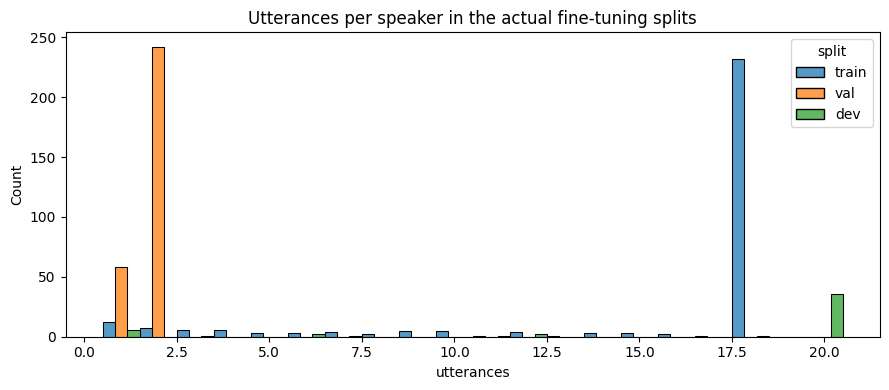

In [9]:
# Utterances per speaker: this reveals the effective impact of MAX_UTTS.
import matplotlib.pyplot as plt
import seaborn as sns

counts = pd.concat([
    df.assign(split=name).groupby(['split', 'speaker_id']).size().rename('utterances')
    for name, df in splits.items()
]).reset_index()
display(counts.groupby('split')['utterances'].describe())
plt.figure(figsize=(9, 4))
sns.histplot(data=counts, x='utterances', hue='split', multiple='dodge', discrete=True)
plt.title('Utterances per speaker in the actual fine-tuning splits')
plt.tight_layout()
plt.show()

Unreadable audio files: 0


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
dev,801.0,8.268814,7.772512,0.84,3.240000,5.24,10.440000,38.840000
train,4624.0,7.762185,7.145643,0.84,3.240000,5.24,9.640000,39.896375
val,542.0,7.405404,6.496888,0.84,2.882156,4.84,9.585313,38.840000


,speaker_id,path,split,duration_seconds,sample_rate,read_error
5714,id00658,/content/Vietnam-Celeb/data/id00658/00134.wav,dev,5.24,16000.0,NaN
810,id00049,/content/Vietnam-Celeb/data/id00049/00002.wav,train,2.04,16000.0,NaN
2488,id00808,/content/Vietnam-Celeb/data/id00808/00007.wav,train,13.64,16000.0,NaN
2941,id00268,/content/Vietnam-Celeb/data/id00268/00037.wav,train,4.84,16000.0,NaN
4681,id00494,/content/Vietnam-Celeb/data/id00494/00052.wav,val,7.24,16000.0,NaN
2718,id00355,/content/Vietnam-Celeb/data/id00355/00028.wav,train,8.84,16000.0,NaN
1047,id00256,/content/Vietnam-Celeb/data/id00256/00003.wav,train,3.64,16000.0,NaN
4391,id00171,/content/Vietnam-Celeb/data/id00171/00007.wav,train,2.04,16000.0,NaN
79,id00425,/content/Vietnam-Celeb/data/id00425/00014.wav,train,4.44,16000.0,NaN
5661,id00163,/content/Vietnam-Celeb/data/id00163/00000.wav,dev,8.44,16000.0,NaN


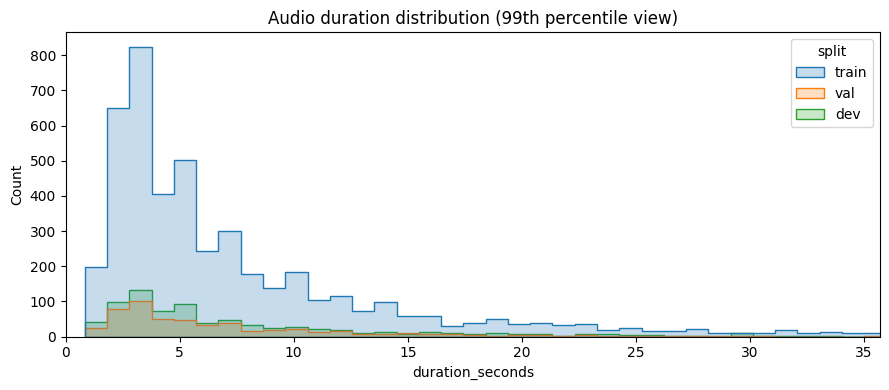

In [10]:
# Audio duration EDA uses headers only; unreadable files are reported rather than silently dropped.
import soundfile as sf

all_rows = pd.concat([df.assign(split=name) for name, df in splits.items()], ignore_index=True)
def audio_info(path):
    try:
        info = sf.info(path)
        return pd.Series({'duration_seconds': info.duration, 'sample_rate': info.samplerate, 'read_error': None})
    except Exception as exc:
        return pd.Series({'duration_seconds': None, 'sample_rate': None, 'read_error': str(exc)})

audio_stats = all_rows.join(all_rows.path.apply(audio_info))
print('Unreadable audio files:', int(audio_stats.read_error.notna().sum()))
display(audio_stats.groupby('split')['duration_seconds'].describe())
display(audio_stats.sample(min(10, len(audio_stats)), random_state=SEED))
plt.figure(figsize=(9, 4))
sns.histplot(data=audio_stats.dropna(subset=['duration_seconds']), x='duration_seconds', hue='split', bins=40, element='step')
plt.xlim(0, audio_stats.duration_seconds.quantile(0.99))
plt.title('Audio duration distribution (99th percentile view)')
plt.tight_layout()
plt.show()

In [43]:
# Listen to one file from the exact train split (optional).
from IPython.display import Audio, display
sample_path = splits['train'].sample(20, random_state=5942).iloc[0].path
print(sample_path)
display(Audio(sample_path))

/content/Vietnam-Celeb/data/id00162/00013.wav


## Interpretation checklist
- Report counts from `overview`, not counts from Vietnam-Celeb-E/H.
- Keep `SEED`, `TRAIN_SPEAKERS`, `DEV_SPEAKERS`, and `MAX_UTTS` identical to the fine-tune command when making report figures.
- The resulting `METADATA_DIR/train.csv` and `val.csv` are the files to pass to `finetune_ecapa_colab.py`; `dev.csv` is for verification evaluation.